#  Lotka volterra equation 
In the 1920s, the Italian mathematician Vito Volterra proposed a differential equation model to describe the population dynamics of two interacting species, a predator and its prey. He hoped to explain the observed increase in predator fish (and corresponding decrease in prey fish) in the Adriatic Sea during World War I. Such mathematical models have long proven useful in describing how populations vary over time. Data about the various rates of growth, death, and interaction of species naturally lead to models involving differential equations. Independently, in the United States, the very equations studied by Volterra were derived by Alfred Lotka  to describe a hypothetical chemical reaction in which the chemical concentrations oscillate.

The Lotka-Volterra model consists of the following system of differential equations-
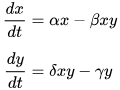

From the above equation, the parameters can be thought of as the following:

* $\frac{dx}{dt}$ = growth rate of prey(public population)
* $\frac{dy}{dt}$ = growth rate of predator(cheater population)

* $x$ =  (prey) population 
* $y$ = (predator) population

* $\alpha$ = growth rate of prey(public) in the absence of predators(cheater)
* $\beta$ = effect on predation on prey
* $\gamma$ = natural death rate of predator(cheater)
* $\delta$ = factor describing how many consumed prey create a new predator


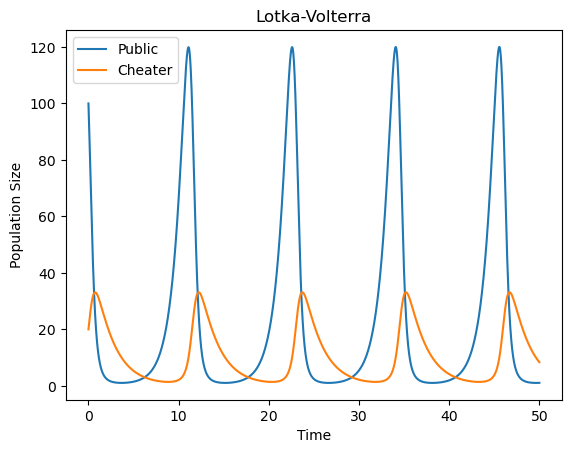

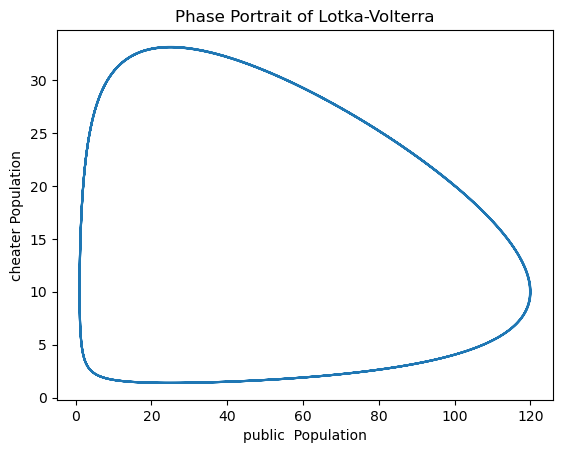

In [28]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as npy
import random

# timestep determines the accuracy of the euler method of integration
timestep = 0.0001
# amplitude of noise term
amp = 0.00
# the time at which the simulation ends
end_time = 50

# creates a time vector from 0 to end_time, seperated by a timestep
t = npy.arange(0,end_time,timestep)

# intialize public (x) and cheater (y) vectors
x = []
y = []

# noise term to perturb differential equations
def StochasticTerm(amp):
    return (amp * random.uniform(-1,1))

"""" definition of lotka-volterra parameters"""
# growth rate public
a = 1
# growth rate reduction of public due to cheater
b = 0.1
# natural death rate of cheater
c = 0.5
# factor that describes how much public resource  grow a new cheater
d = 0.02

""" euler integration """

# initial conditions for the public (x) and cheater (y) populations at time=0
x.append(100)
y.append(20)

# forward euler method of integration
# a perturbbation term is added to the differentials to make the simulation stochastic
for index in range(1,len(t)):
    
    # make parameters stochastic
#     a = a + StochasticTerm(amp)
#     b = b + StochasticTerm(amp)
#     c = c + StochasticTerm(amp)
#     d = d + StochasticTerm(amp)
    
    # evaluate the current differentials
    xd = x[index-1] * (a - b*y[index-1])
    yd = -y[index-1]*(c - d*x[index-1])
    
    # evaluate the next value of x and y using differentials
    next_x = x[index-1] + xd * timestep
    next_y = y[index-1] + yd * timestep

    # add the next value of x and y 
    x.append(next_x)
    y.append(next_y)

""" visualization """

if amp == 0:    
    # visualization of deterministic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Public', 'Cheater'))
    plt.title('Lotka-Volterra')
    plt.show()

    # deterministic phase portrait
    plt.plot(x,y)
    plt.xlabel('public  Population')
    plt.ylabel('cheater Population')
    plt.title('Phase Portrait of Lotka-Volterra')
    plt.show()
    
else:
    # visualization of stochastic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Public', 'Cheater'))
    plt.title('Stochastic Lotka-Volterra')
    plt.show()

    # stochastic phase portrait
    plt.plot(x,y)
    plt.xlabel('public Population')
    plt.ylabel('cheater Population')
    plt.title('Phase Portrait of Stochastic Lotka-Volterra')
    plt.show()
    
    # noise term visualization
    noise = []
    n =[]
    for sample in range(100):
        noise.append(StochasticTerm(amp))
        n.append(sample)

    plt.plot(n, noise)
    plt.xlabel('Arbitrary Noise Samples')
    plt.ylabel('Noise')
    plt.title('Perturbation to Birth Rate')
    plt.show()

## Discussion

From the first graph, we observe an oscillatory relationship between the public and the cheater. As the public population grows in size, the cheater population have more resource for growth. This creates more cheater population. As there are now more cheater, they more rapidly consume the public population resource. As the public population is depleted by the large number of cheater, the cheater have less for resource and are therefore depleted as well.

From the second graph, we observe a closed loop for the phase portrait. This demonstrates the __stability__ of these differential equations, subject to the Euler method. 

### Errors in the Simulation

The errors in our numerical simulation are due to the integration method chosen for evaluating populations. 

The numerical integration method chosen was the Euler method. Inherrent errors within this method include the stepsize chosen, which contributes to a discretization error, and any rounding errors.

The dominant error in our program is the discretization error, which can be minimized by decreasing the step-size. It is worth noting that when the step-size is larger, the closed-loop observed becomes a spiral, and the populations diverge. This illustrates that the equations are mathematically "__unstable__".

This can be further illustrated by evaluating the Jacobian matrix of the populations.

## Steady States of the Populations

The steady state of the populations arises when the growth rates are equal to zero.

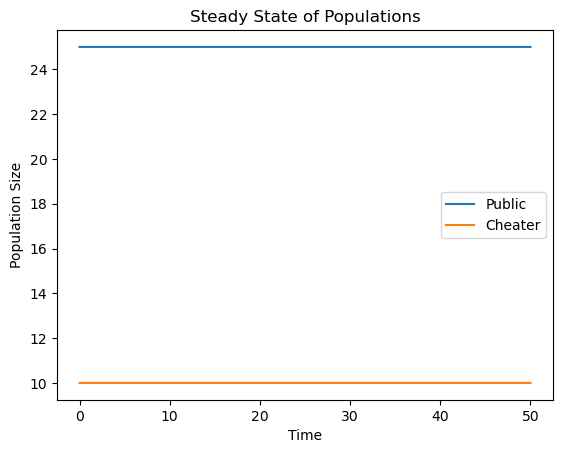

In [5]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as npy
import random

# timestep determines the accuracy of the euler method of integration
timestep = 0.001
# amplitude of noise term
amp = 0.
# the time at which the simulation ends
end_time = 50

# creates a time vector from 0 to end_time, seperated by a timestep
t = npy.arange(0,end_time,timestep)

# intialize rabbits (x) and foxes (y) vectors
x = []
y = []

# noise term to perturb differential equations
def StochasticTerm(amp):
    return (amp * random.uniform(-1,1))

"""" definition of lotka-volterra parameters"""
# growth rate public
a = 1
# growth rate reduction of public due to cheater
b = 0.1
# natural death rate of cheater
c = 0.5
# factor that describes how much public resource  grow a new cheater
d = 0.02

""" euler integration """

# initial conditions for the public(x) and cheater (y) populations at time=0
x.append(c/d)
y.append(a/b) 

# forward euler method of integration
# a perturbbation term is added to the differentials to make the simulation stochastic
for index in range(1,len(t)):
    
    # make parameters stochastic
#     a = a + StochasticTerm(amp)
#     b = b + StochasticTerm(amp)
#     c = c + StochasticTerm(amp)
#     d = d + StochasticTerm(amp)
    
    # evaluate the current differentials
    xd = x[index-1] * (a - b*y[index-1])
    yd = -y[index-1]*(c - d*x[index-1])
    
    # evaluate the next value of x and y using differentials
    next_x = x[index-1] + xd * timestep
    next_y = y[index-1] + yd * timestep

    # add the next value of x and y 
    # add noise to x and y
    x.append(next_x + StochasticTerm(amp))
    y.append(next_y)

""" visualization """

if amp == 0:    
    # visualization of deterministic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Public', 'Cheater'))
    plt.title('Steady State of Populations')
    plt.show()

## Stochastic Birth Rate

Here, the value of the birth rate a is defined to be stochastic in the integration.

We define a as follows:

a = a + StochasticTerm

Therefore, the value of a has a mean about the deterministic value of a, but it has an added noise to it that varies proportionally with the birth rate.

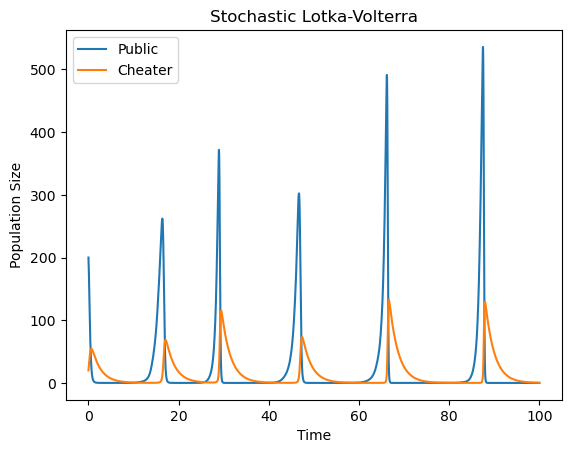

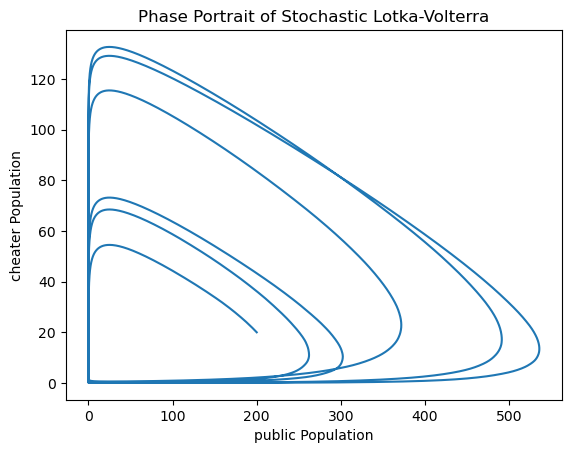

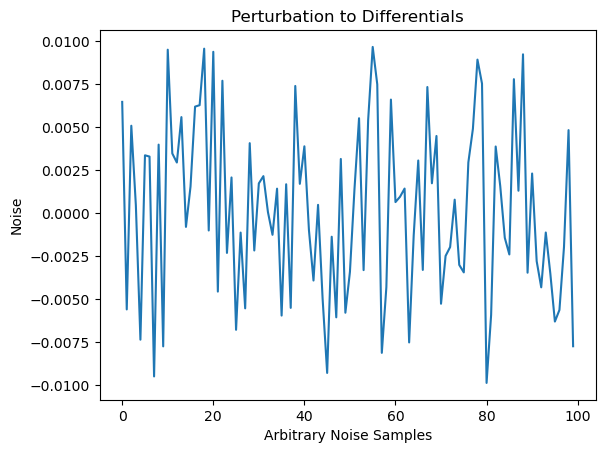

In [29]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as npy
import random

# timestep determines the accuracy of the euler method of integration
timestep = 0.001
# amplitude of noise term
amp = 0.01
# the time at which the simulation ends
end_time = 100

# creates a time vector from 0 to end_time, seperated by a timestep
t = npy.arange(0,end_time,timestep)

# intialize rabbits (x) and foxes (y) vectors
x = []
y = []

# noise term to perturb differential equations
def StochasticTerm(amp):
    return (amp * random.uniform(-1,1))

"""" definition of lotka-volterra parameters"""
# growth rate public
a = 1
# growth rate reduction of public due to cheater
b = 0.1
# natural death rate of cheater
c = 0.5
# factor that describes how much public resource  grow a new cheater
d = 0.02


""" euler integration """

# initial conditions for the public (x) and cheater (y) populations at time=0
x.append(200)
y.append(20) 

# forward euler method of integration
# a perturbbation term is added to the differentials to make the simulation stochastic
for index in range(1,len(t)):
    
    # make parameters stochastic
    a = a + StochasticTerm(amp)
#     b = b + StochasticTerm(amp)
#     c = c + StochasticTerm(amp)
#     d = d + StochasticTerm(amp)
    
    # evaluate the current differentials
    xd = x[index-1] * (a - b*y[index-1])
    yd = -y[index-1]*(c - d*x[index-1])
    
    # evaluate the next value of x and y using differentials
    next_x = x[index-1] + xd * timestep
    next_y = y[index-1] + yd * timestep

    # add the next value of x and y 
    # add noise to x and y
    x.append(next_x)
    y.append(next_y)

""" visualization """

if amp == 0:    
    # visualization of deterministic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Public', 'Cheater'))
    plt.title('Deterministic Lotka-Volterra')
    plt.show()

    # deterministic phase portrait
    plt.plot(x,y)
    plt.xlabel('Cheater Population')
    plt.ylabel('Public Population')
    plt.title('Phase Portrait of Deterministic Lotka-Volterra')
    plt.show()
    
else:
    # visualization of stochastic populations against time
    plt.plot(t, x)
    plt.plot(t, y)
    plt.xlabel('Time')
    plt.ylabel('Population Size')
    plt.legend(('Public', 'Cheater'))
    plt.title('Stochastic Lotka-Volterra')
    plt.show()

    # stochastic phase portrait
    plt.plot(x,y)
    plt.xlabel('public Population')
    plt.ylabel('cheater Population')
    plt.title('Phase Portrait of Stochastic Lotka-Volterra')
    plt.show()
    
    # noise term visualization
    noise = []
    n =[]
    for sample in range(100):
        noise.append(StochasticTerm(amp))
        n.append(sample)

    plt.plot(n, noise)
    plt.xlabel('Arbitrary Noise Samples')
    plt.ylabel('Noise')
    plt.title('Perturbation to Differentials')
    plt.show()
    

## Discussion

Here, we observe that the populations start out relatively stable, but as the simulation evolves the populations begin to oscillate with greater and greater amplitude as the public population is continuously subject to the uniformly distributed noise.

Once the public population is perturbed out of its steady state, the cheater population experiences a non-zero change to its differential, which perturbs it also out of its steady state. Therefore, if a small change is made to only one species, the other species will also be perturbed out of its steady state. This then causes both species to exhibt the oscillatory behaviour.

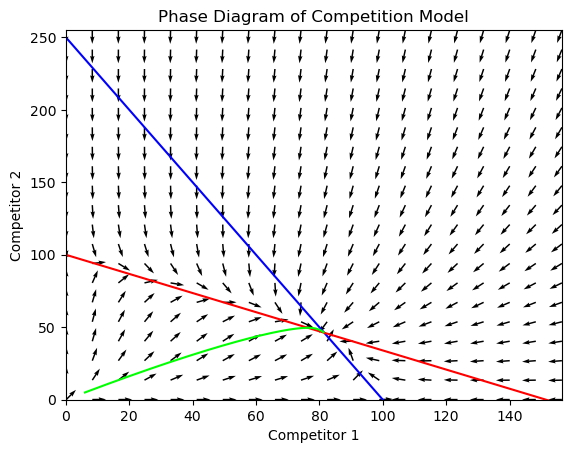

In [1]:
# 1. Import libraries
import numpy as np                   
import matplotlib.pyplot as plt      
import scipy as sci                  
from scipy import integrate


#2. Define the ODE function 
def LVC(N, t, r1, r2, alpha, beta, K1, K2):
    """Lotka-Volterra Competition Model"""
    dN_1 = r1*N[0] * (1 - (N[0] + alpha * N[1])/ K1)
    dN_2 = r2*N[1] * (1 - (N[1] + beta * N[0])/ K2)
    return(np.array([dN_1, dN_2]))

#3. Parameters values and initial conditions
r1 = 0.1
r2 = 0.1
alpha = 0.4 # Change this parameter to obtain different scenarios of LV model
beta = 0.66 # Change this parameter to obtain different scenarios of LV model
K1 = 100
K2 = 100

NI = np.array([6, 5]) # Initial conditions (Initial population sizes)

#4. Time vector
t = np.linspace(0, 150, 1000)

#5. Solving the system of differential equations
sol = sci.integrate.odeint(LVC, NI, t, args=(r1, r2, alpha, beta, K1, K2))

#6 Create the chart
#plt.plot(t, sol[:, 0], color = "blue", label = "Competitor 1")
#plt.plot(t, sol[:, 1], color = "red", label = "Competitor 2")
#plt.legend(loc = "upper right")
#plt.xlabel("Time")
#plt.ylabel("Population size")
#plt.show()




# Phase Diagram. Multiples scenarios
N_1 = np.linspace(0, np.max([K1, K2/beta])+5, 100)
N_2 = np.linspace(0, np.max([K2, K1/alpha])+5, 100)
Null_N1 = (K1 - N_1)/alpha
Null_N2 = K2 - beta * N_1

N1_max = np.max(N_1) # Max value of competitor 1
N2_max = np.max(N_2) # Max value of competitor 2
x = np.linspace(0.1, N1_max, 20) # Obtaining a vector with "X (here 20, see third argument)" values from 0 to N1_max"
y = np.linspace(0.1, N2_max, 20) # Obtaining a vector with "X (here 20, see third argument)" values from 0 to N2_max"
xx, yy = np.meshgrid(x, y) # Creating a meshgrid with points where the vector will be drawn.
NN1, NN2 = LVC((xx, yy), 0, r1, r2, alpha, beta, K1, K2) # Derivate each point of the Phase Diagram (it will create the vector field)
norm = np.sqrt(NN1**2 + NN2**2)
NN1 = NN1 / norm
NN2 = NN2 / norm
plt.quiver(xx, yy, NN1, NN2, cmap=plt.cm.gray) #
plt.plot(N_1, Null_N1, color = "blue")
plt.plot(N_1, Null_N2, color = "red")
plt.plot(sol[:, 0], sol[:, 1], color = "lime")
plt.xlim(0, N1_max)
plt.ylim(0, N2_max)
plt.title("Phase Diagram of Competition Model")
plt.xlabel("Competitor 1")
plt.ylabel("Competitor 2")
plt.show() 

Here are the equilibrium points for the system:

1. $(C, D, P) = (0, 0, 0) (\frac{\nu}{\alpha}, 0, 0), (\frac{r_p}{\eta}, 0, 0), (\frac{\nu}{\alpha}, \frac{r_c - \beta P}{\alpha}, 0),(\frac{r_p}{\eta}, 0, \frac{r_c - \alpha D}{\beta}), (\frac{\nu}{\alpha}, \frac{r_c - \beta P}{\alpha}, \frac{r_p - \eta C}{\beta}) $


























# Quardatic lotka volterra equation analysis

  \begin{equation*}
    \frac{dC}{dt}= r_c \cdot C - \alpha \cdot C\cdot D - \beta \cdot C \cdot P - \lambda \cdot C ^2
\end{equation*}

\begin{equation*}
    \frac{dD}{dt}= \alpha C\cdot D - \nu \cdot D^2
\end{equation*}

\begin{equation*}
    \frac{dP}{dt}= r_P \cdot P - \eta P \cdot C - \gamma \cdot P^2
\end{equation*}







$r_c, r_p =$  natural growth rate of public and private in Monoculture.
Effect of P on C population = $\beta$,  Benefit shearing( Public to Cheater) = $\alpha$,  Effect of C on Q  Population =$\eta$, and Effect of other cheater Population  = $\nu$, Effect of other Public Population  = $\lambda$, Effect of other Private Population  = $\gamma$





###  Equilibrium Point:
$( \frac{\nu}{\alpha}, \frac{r_c - \frac{\beta}{\gamma} \cdot (r_P - \eta \cdot \frac{\nu}{\alpha}) - \lambda \cdot \frac{\nu}{\alpha}}{\alpha}, \frac{r_P - \eta \cdot \frac{\nu}{\alpha}}{\gamma})
$

This is the equilibrium point where all three populations coexist.


### Step 1: Express the Jacobian Matrix
The Jacobian matrix is:
$$
J(C^*, D^*, P^*) = \begin{pmatrix}
r_c - \alpha D^* - \beta P^* - 2\lambda C^* & -\alpha C^* & -\beta C^* \\
\alpha D^* & \alpha C^* - \nu & 0 \\
-\eta P^* & 0 & r_P - \eta C^* - 2\gamma P^*
\end{pmatrix}
$$

### Step 2: Substitute the Equilibrium Points

$$
J(C^*, D^*, P^*) = \begin{pmatrix}
r_c - \frac{r_c - \frac{\beta}{\gamma} \left(r_P - \eta \cdot \frac{\nu}{\alpha}\right) - \lambda \cdot \frac{\nu}{\alpha}}{\alpha} - \frac{\beta \left(r_P - \eta \cdot \frac{\nu}{\alpha}\right)}{\gamma} - 2\lambda \cdot \frac{\nu}{\alpha} & -\nu/\alpha & -\beta \cdot \nu/\alpha \\
\frac{r_c - \frac{\beta}{\gamma} \cdot \left(r_P - \eta \cdot \frac{\nu}{\alpha}\right) - \lambda \cdot \frac{\nu}{\alpha}}{\alpha} & \nu - \nu & 0 \\
-\eta \cdot \frac{r_P - \eta \cdot \frac{\nu}{\alpha}}{\gamma} & 0 & \frac{r_P - \eta \cdot \nu/\alpha - 2\gamma \cdot \left(r_P - \eta \cdot \frac{\nu}{\alpha}\right)}{\gamma}
\end{pmatrix}
$$

### Step 4: Eigenvalue Calculation

The eigenvalues $\lambda $ of the matrix $ J $ are found by solving the characteristic equation:

$$
\det(J - \lambda I) = 0
\$$

Where $ I $ is the identity matrix. This involves calculating the determinant of the matrix $(J - \lambda I)$ and setting it equal to zero.

Given the complexity of this step, we would solve the characteristic polynomial:

$$
\lambda^3 + a_2\lambda^2 + a_1\lambda + a_0 = 0
$$

Where $(a_2)$, $(a_1)$, and $(a_0)$ are coefficients that depend on the entries of the Jacobian matrix.


Equilibrium Point: [  82.34194377   82.91157485 1675.07114458]
Eigenvalues: [ 0.04845994+0.07573743j  0.04845994-0.07573743j -0.01446118+0.j        ]
Unstable equilibrium.


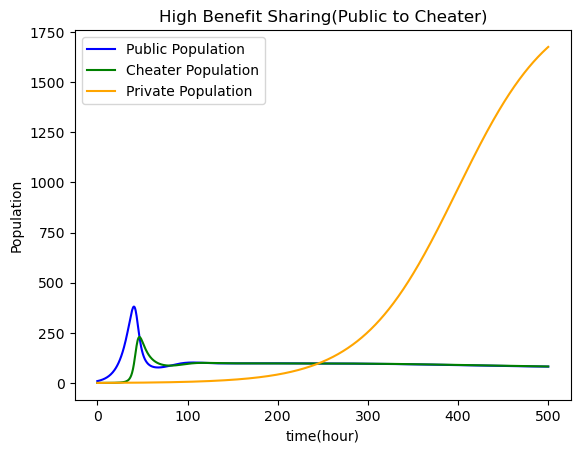

In [11]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .02  # growth rate (benefit) of private
nu = 0.001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 10.0, 1.0, 1.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 500, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plotgame(t, C, D, P)
plt.title('High Benefit Sharing(Public to Cheater)')
plt.show()


## Eigenvalue analysis

In [12]:
import numpy as np
from scipy.optimize import fsolve
from scipy.linalg import eigvals

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C
    dDdt = -nu * D * D + alpha * C * D
    dPdt = eta * P - beta * C * P - gamma * P * P
    return dCdt, dDdt, dPdt

def find_equilibrium(nu, beta, alpha, mu, gamma, eta):
    # Function to find equilibrium point by setting derivatives to zero
    equilibrium_func = lambda y: deriv(y, 0, nu, beta, alpha, mu, gamma, eta)
    # Initial guess for the equilibrium point
    initial_guess = [0, 0, 0]
    # Use fsolve to find the root (equilibrium point)
    equilibrium_point = fsolve(equilibrium_func, initial_guess)
    return equilibrium_point

def calculate_eigenvalues(equilibrium_point, nu, beta, alpha, mu, gamma, eta):
    # Jacobian matrix at equilibrium point
    J = np.array([
        [mu - alpha * equilibrium_point[1] - 2 * beta * equilibrium_point[0], -alpha * equilibrium_point[0], -beta * equilibrium_point[0]],
        [alpha * equilibrium_point[1], -nu + alpha * equilibrium_point[0], 0],
        [-beta * equilibrium_point[2], 0, eta - beta * equilibrium_point[0] - 2 * gamma * equilibrium_point[2]]
    ])
    # Calculate eigenvalues of the Jacobian matrix
    eigenvalues = eigvals(J)
    return eigenvalues

# Input parameter values
beta = float(input("Enter the value for beta: "))
gamma = float(input("Enter the value for gamma: "))
alpha = float(input("Enter the value for alpha: "))
mu = float(input("Enter the value for mu: "))
eta = float(input("Enter the value for eta: "))
nu = float(input("Enter the value for nu: "))

# Find equilibrium point
equilibrium_point = find_equilibrium(nu, beta, alpha, mu, gamma, eta)
print("Equilibrium Point:", equilibrium_point)

# Calculate eigenvalues at equilibrium point
eigenvalues = calculate_eigenvalues(equilibrium_point, nu, beta, alpha, mu, gamma, eta)
print("Eigenvalues:", eigenvalues)


Enter the value for beta: 0.0001
Enter the value for gamma: 0.001
Enter the value for alpha: 0.01
Enter the value for mu: 0.00001
Enter the value for eta: 0.000001
Enter the value for nu: 0.0000002
Equilibrium Point: [0. 0. 0.]
Eigenvalues: [ 1.e-05+0.j -2.e-07+0.j  1.e-06+0.j]


Equilibrium Point: [  13.69863409   62.10193801 9985.33777703]
Eigenvalues: [ 0.09349434+0.j -0.09991443+0.j  0.00136204+0.j]
Unstable equilibrium.


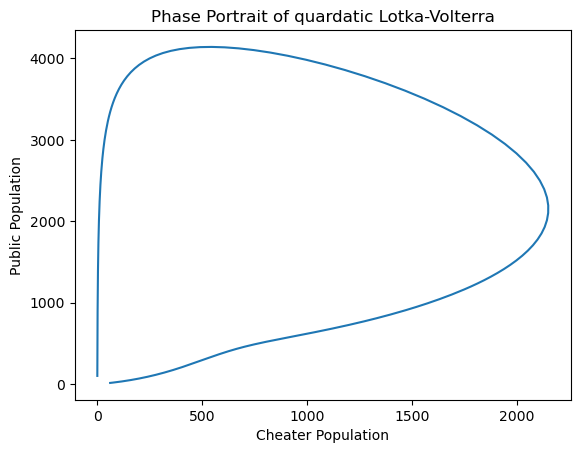

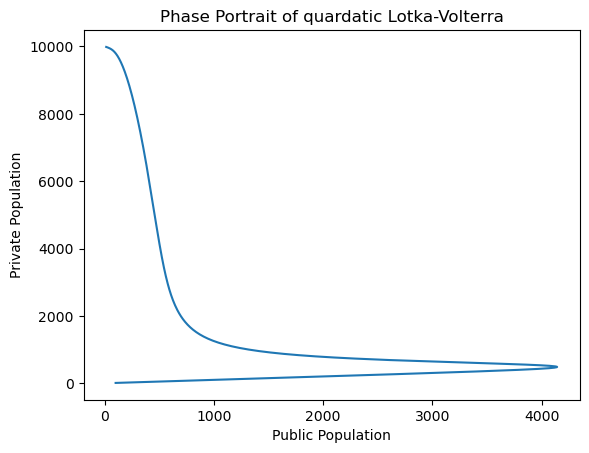

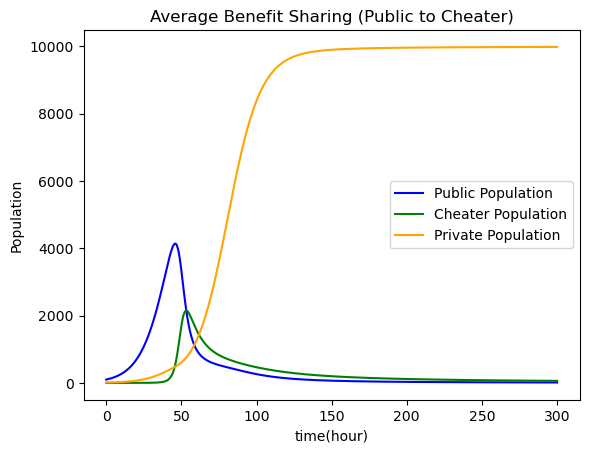

In [5]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .1  # growth rate (benefit) of private
nu = 0.0001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 100.0, 1.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 300, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plt.plot(D,C)
plt.xlabel('Cheater Population')
plt.ylabel('Public Population')
plt.title('Phase Portrait of quardatic Lotka-Volterra')
plt.show()

plt.plot(C,P)
plt.xlabel('Public Population')
plt.ylabel('Private Population')
plt.title('Phase Portrait of quardatic Lotka-Volterra')
plt.show()

plotgame(t, C, D, P)
plt.title('Average Benefit Sharing (Public to Cheater)')
plt.show()



Equilibrium Point: [82.56880734  8.25688073 91.74311927]
Eigenvalues: [ 6.1456979 +0.j  1.12465024+0.j -0.92172429+0.j]
Unstable equilibrium.


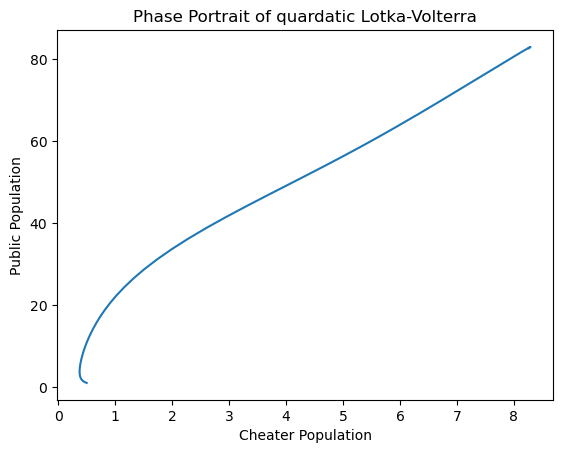

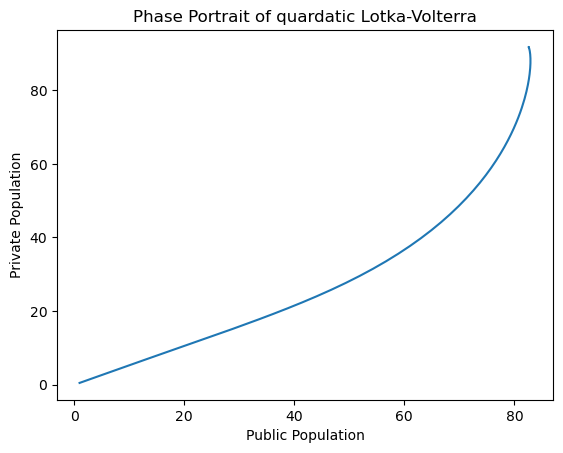

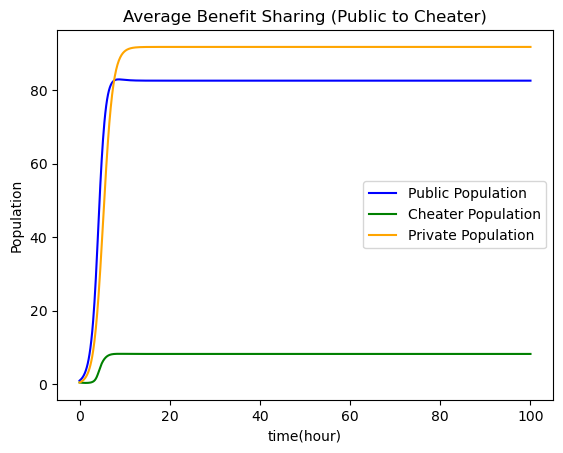

In [2]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
#beta = 0.00001  # benefit from cooperator to private
#gamma = 0.00001  # cost spent by private population
#alpha = 0.0001  # benefit from cooperator to defector
#mu = .1 # growth rate (benefit) of cooperator
#eta = .1  # growth rate (benefit) of private
#nu = 0.0001  # transportation cost of defector

# Parameters
beta = 0.001  # benefit from cooperator to private
gamma = 0.01  # cost spent by private population
alpha = .1  # benefit from cooperator to defector
mu = 1 # growth rate (benefit) of cooperator
eta = 1  # growth rate (benefit) of private
nu = 1  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1.0, 0.5, 0.5
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 100, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plt.plot(D,C)
plt.xlabel('Cheater Population')
plt.ylabel('Public Population')
plt.title('Phase Portrait of quardatic Lotka-Volterra')
plt.show()

plt.plot(C,P)
plt.xlabel('Public Population')
plt.ylabel('Private Population')
plt.title('Phase Portrait of quardatic Lotka-Volterra')
plt.show()

plotgame(t, C, D, P)
plt.title('Average Benefit Sharing (Public to Cheater)')
plt.show()


## Analysis of the Model
#


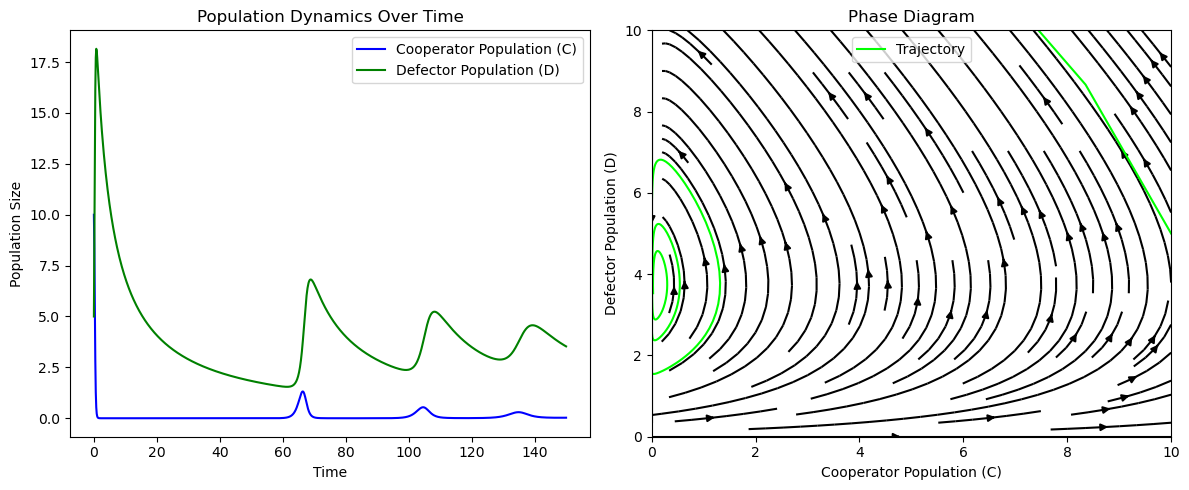

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function based on the given equations
def competition_model(N, t, rc, alpha, nu, lambda_):
    C, D = N
    dCdt = rc * C - alpha * C * D - lambda_ * C**2
    dDdt = alpha * C * D - nu * D**2
    return np.array([dCdt, dDdt])

# Parameters values
rc = 1.5  # Growth rate of cooperator population
alpha = 0.4  # Interaction coefficient
nu = .01  # Cost for defector population
lambda_ = 0.001  # Self-limitation coefficient of cooperator population

# Initial conditions
C0, D0 = 10, 5  # Initial population sizes

# Time vector
t = np.linspace(0, 150, 1000)

# Solving the system of differential equations
sol = odeint(competition_model, [C0, D0], t, args=(rc, alpha, nu, lambda_))

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot time evolution
plt.subplot(1, 2, 1)
plt.plot(t, sol[:, 0], 'b', label='Cooperator Population (C)')
plt.plot(t, sol[:, 1], 'g', label='Defector Population (D)')
plt.title('Population Dynamics Over Time')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.legend()

# Phase Diagram
C, D = np.meshgrid(np.linspace(0, 10, 20), np.linspace(0, 10, 20))
dCdt, dDdt = competition_model([C, D], 0, rc, alpha, nu, lambda_)
norm = np.sqrt(dCdt**2 + dDdt**2)
plt.subplot(1, 2, 2)
plt.streamplot(C, D, dCdt, dDdt, color='k')
plt.plot(sol[:, 0], sol[:, 1], 'lime', label='Trajectory')
plt.title('Phase Diagram')
plt.xlabel('Cooperator Population (C)')
plt.ylabel('Defector Population (D)')
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.legend()

plt.tight_layout()
plt.show()


Public and Private population (compitation)

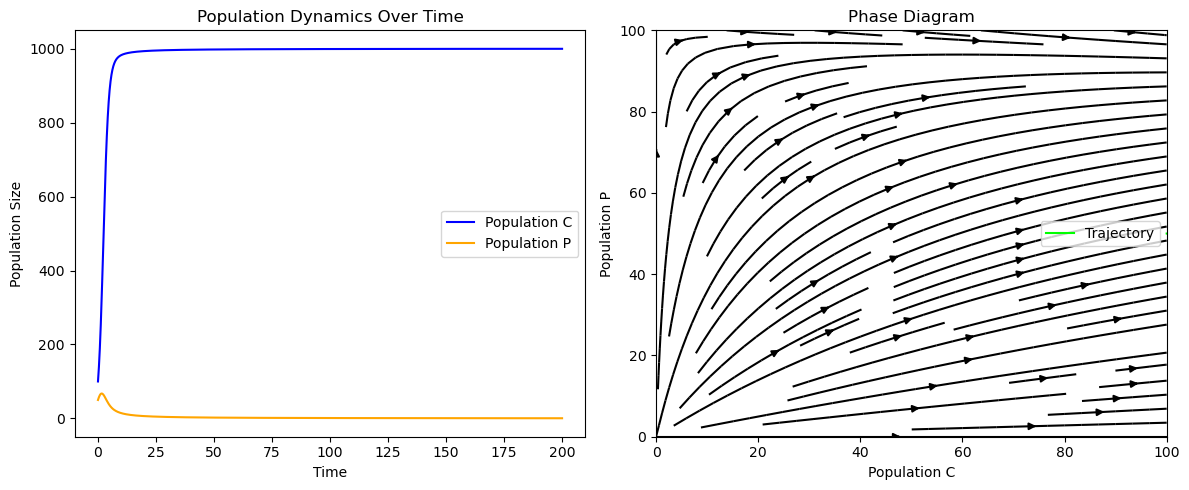

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function for populations C and P
def population_dynamics(N, t, r_c, r_p, alpha, beta, lambda_, gamma):
    C, P = N
    dCdt = r_c * C - alpha * C * P - lambda_ * C**2  # Dynamics of population C
    dPdt = r_p * P - beta * P * C - gamma * P**2     # Dynamics of population P
    return np.array([dCdt, dPdt])

# Parameters values
r_c = 1.0  # Growth rate of population C
r_p = 1.0  # Growth rate of population P
alpha = 0.001  # Impact of P on C
beta = 0.001  # Impact of C on P
lambda_ = 0.001  # Self-limitation coefficient of C
gamma = 0.01  # Self-limitation coefficient of P

# Initial conditions
C0, P0 = 100, 50  # Initial population sizes

# Time vector
t = np.linspace(0, 200, 1000)

# Solving the system of differential equations
sol = odeint(population_dynamics, [C0, P0], t, args=(r_c, r_p, alpha, beta, lambda_, gamma))

# Plotting the results
plt.figure(figsize=(12, 5))

# Plot time evolution
plt.subplot(1, 2, 1)
plt.plot(t, sol[:, 0], 'b', label='Population C')
plt.plot(t, sol[:, 1], 'orange', label='Population P')
plt.title('Population Dynamics Over Time')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.legend()

# Phase Diagram
C, P = np.meshgrid(np.linspace(0, 100, 20), np.linspace(0, 100, 20))
dCdt, dPdt = population_dynamics([C, P], 0, r_c, r_p, alpha, beta, lambda_, gamma)
plt.subplot(1, 2, 2)
plt.streamplot(C, P, dCdt, dPdt, color='k')
plt.plot(sol[:, 0], sol[:, 1], 'lime', label='Trajectory')
plt.title('Phase Diagram')
plt.xlabel('Population C')
plt.ylabel('Population P')
plt.xlim([0, 100])
plt.ylim([0, 100])
plt.legend()

plt.tight_layout()
plt.show()


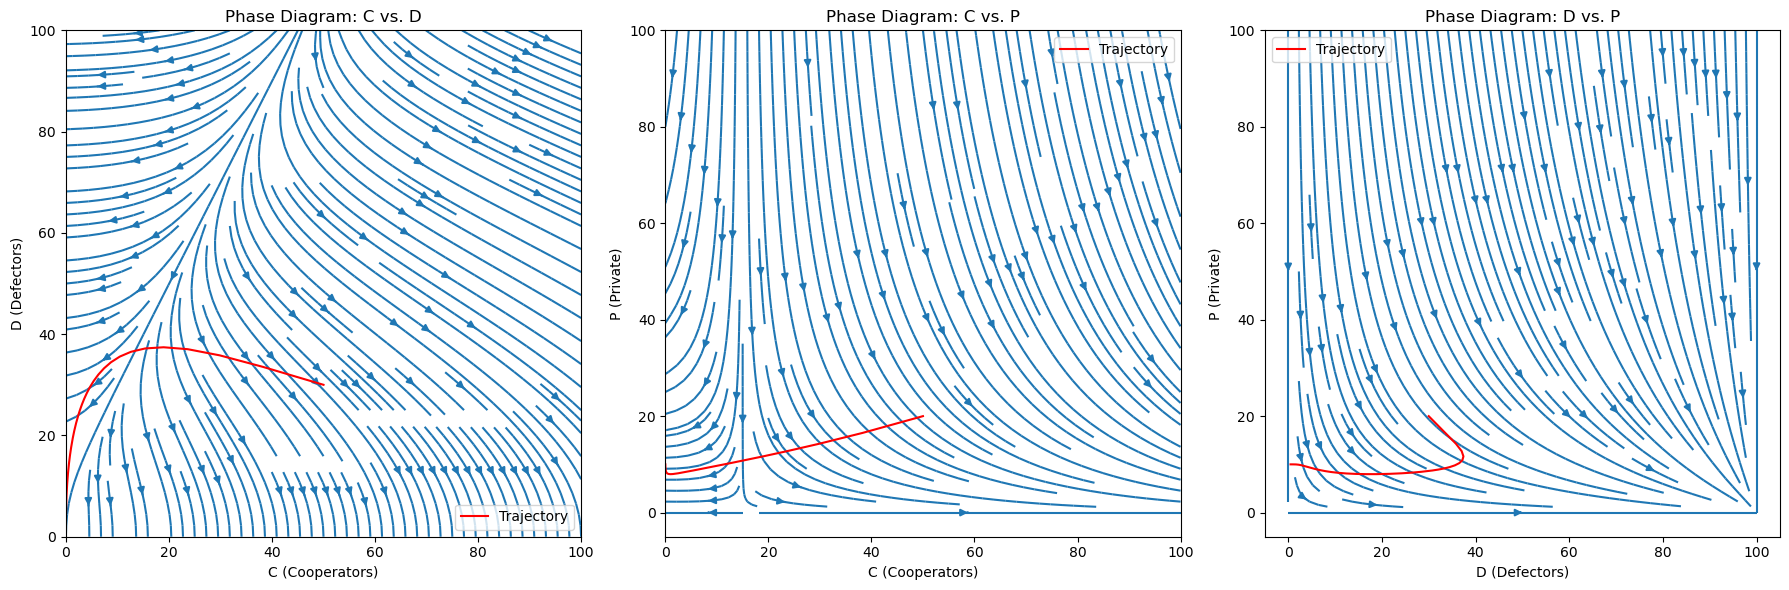

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ODE function for populations C, D, and P
def population_dynamics(N, t, rc, alpha, beta, nu, eta, lambda_, gamma):
    C, D, P = N
    dCdt = rc * C - alpha * C * D - beta * C * P - lambda_ * C**2
    dDdt = alpha * C * D - nu * D**2
    dPdt = eta * P - beta * P * C - gamma * P**2
    return np.array([dCdt, dDdt, dPdt])

# Parameters
rc, alpha, beta, nu, eta, lambda_, gamma = 0.1, 0.02, 0.02, 0.01, 0.1, 0.01, 0.01

# Initial conditions
C0, D0, P0 = 50, 30, 20

# Time vector
t = np.linspace(0, 200, 1000)

# Solve ODEs
sol = odeint(population_dynamics, [C0, D0, P0], t, args=(rc, alpha, beta, nu, eta, lambda_, gamma))

# Setup for phase diagrams
C_range = np.linspace(0, 100, 20)
D_range = np.linspace(0, 100, 20)
P_range = np.linspace(0, 100, 20)

# Calculate vector fields
C_grid, D_grid = np.meshgrid(C_range, D_range)
_, dCdt_CD, dDdt_CD = population_dynamics([C_grid, D_grid, np.ones_like(C_grid) * P0], 0, rc, alpha, beta, nu, eta, lambda_, gamma)

C_grid, P_grid = np.meshgrid(C_range, P_range)
_, dCdt_CP, dPdt_CP = population_dynamics([C_grid, np.ones_like(C_grid) * D0, P_grid], 0, rc, alpha, beta, nu, eta, lambda_, gamma)

D_grid, P_grid = np.meshgrid(D_range, P_range)
_, dDdt_DP, dPdt_DP = population_dynamics([np.ones_like(D_grid) * C0, D_grid, P_grid], 0, rc, alpha, beta, nu, eta, lambda_, gamma)

# Plot phase diagrams
plt.figure(figsize=(18, 6))

# C vs. D with streamplot
plt.subplot(1, 3, 1)
plt.streamplot(C_range, D_range, dCdt_CD, dDdt_CD, density=1.5)
plt.plot(sol[:, 0], sol[:, 1], 'r-', label='Trajectory')
plt.xlabel('C (Cooperators)')
plt.ylabel('D (Defectors)')
plt.title('Phase Diagram: C vs. D')
plt.legend()

# C vs. P with streamplot
plt.subplot(1, 3, 2)
plt.streamplot(C_range, P_range, dCdt_CP, dPdt_CP, density=1.5)
plt.plot(sol[:, 0], sol[:, 2], 'r-', label='Trajectory')
plt.xlabel('C (Cooperators)')
plt.ylabel('P (Private)')
plt.title('Phase Diagram: C vs. P')
plt.legend()

# D vs. P with streamplot
plt.subplot(1, 3, 3)
plt.streamplot(D_range, P_range, dDdt_DP, dPdt_DP, density=1.5)
plt.plot(sol[:, 1], sol[:, 2], 'r-', label='Trajectory')
plt.xlabel('D (Defectors)')
plt.ylabel('P (Private)')
plt.title('Phase Diagram: D vs. P')
plt.legend()

plt.tight_layout()
plt.show()


Case 2- Public and cheater 

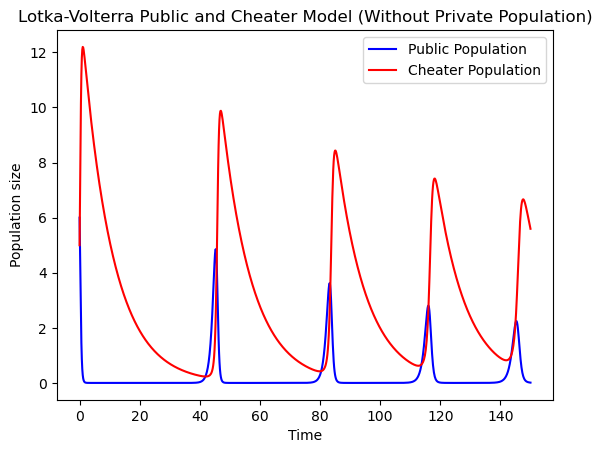

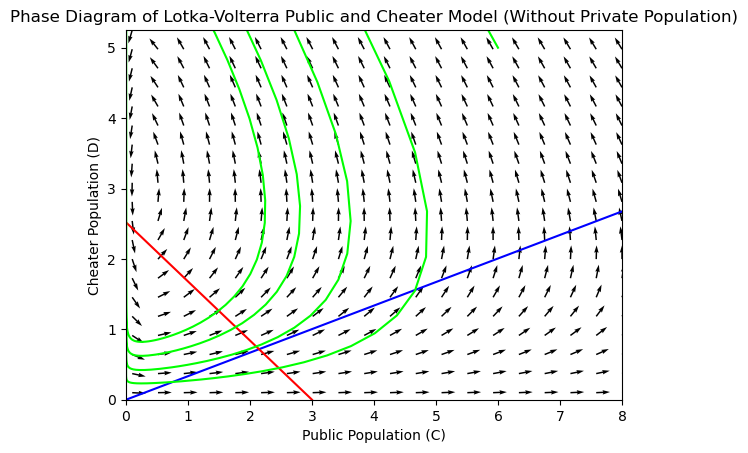

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function
def LVPC(N, t, rc, rp, alpha, beta, nu, lambd):
    """Lotka-Volterra Public and Cheater Model without Private Population"""
    dCdt = rc * N[0] - alpha * N[0] * N[1] - lambd * N[0]**2
    dDdt = alpha * N[0] * N[1] - nu * N[1]
    return np.array([dCdt, dDdt])

# Parameters values and initial conditions
rc =1.2
rp = 0.0
alpha = 0.4  # Change this parameter to obtain different scenarios
beta = 0.66  # Change this parameter to obtain different scenarios
nu = 0.1
lambd = 0.05

NI = np.array([6, 5])  # Initial conditions (Initial population sizes)

# Time vector
t = np.linspace(0, 150, 1000)

# Solving the system of differential equations
sol = odeint(LVPC, NI, t, args=(rc, rp, alpha, beta, nu, lambd))

# Create the chart
plt.plot(t, sol[:, 0], color="blue", label="Public Population")
plt.plot(t, sol[:, 1], color="red", label="Cheater Population")
plt.legend(loc="upper right")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka-Volterra Public and Cheater Model (Without Private Population)")
plt.show()

# Phase Diagram
C = np.linspace(0, np.max([rc/alpha, rp/beta]) + 5, 100)
D = np.linspace(0, np.max([nu/alpha, 0]) + 5, 100)

Null_C = (rc - alpha * D - lambd * C) / alpha
Null_D = alpha * C - nu * D

C_max = np.max(C)
D_max = np.max(D)

x = np.linspace(0.1, C_max, 20)
y = np.linspace(0.1, D_max, 20)

xx, yy = np.meshgrid(x, y)

NNC, NND = LVPC((xx, yy), 0, rc, rp, alpha, beta, nu, lambd)

norm = np.sqrt(NNC**2 + NND**2)
NNC = NNC / norm
NND = NND / norm

plt.quiver(xx, yy, NNC, NND, cmap=plt.cm.gray)
plt.plot(C, Null_D, color="blue")
plt.plot(Null_C, D, color="red")
plt.plot(sol[:, 0], sol[:, 1], color="lime")
plt.xlim(0, C_max)
plt.ylim(0, D_max)
plt.title("Phase Diagram of Lotka-Volterra Public and Cheater Model (Without Private Population)")
plt.xlabel("Public Population (C)")
plt.ylabel("Cheater Population (D)")
plt.show()


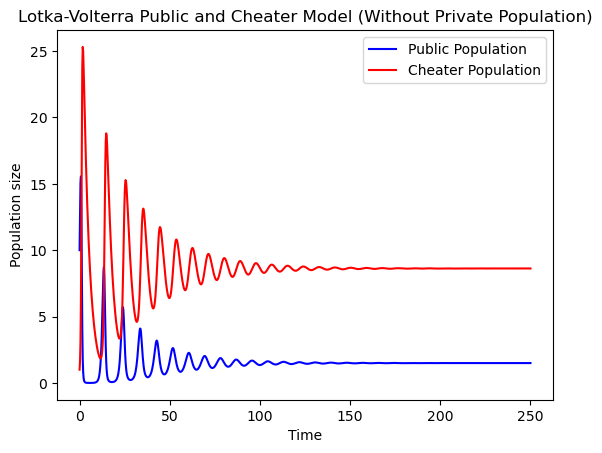

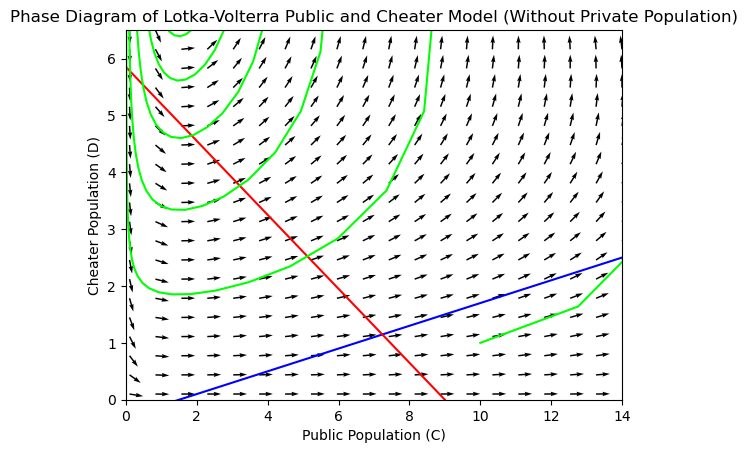

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function
def LVPC(N, t, rc, rp, alpha, beta, nu, lambd):
    """Lotka-Volterra Public and Cheater Model without Private Population"""
    dCdt = rc * N[0] - alpha * N[0] * N[1] - lambd * N[0]**2
    dDdt = alpha * N[0] * N[1] - nu * N[1]
    return np.array([dCdt, dDdt])

# Parameters values and initial conditions
rc =1.8
alpha = 0.2  # Change this parameter to obtain different scenarios
nu = 0.3
lambd = 0.05

NI = np.array([10, 1])  # Initial conditions (Initial population sizes)

# Time vector
t = np.linspace(0, 250, 1000)

# Solving the system of differential equations
sol = odeint(LVPC, NI, t, args=(rc, rp, alpha, beta, nu, lambd))

# Create the chart
plt.plot(t, sol[:, 0], color="blue", label="Public Population")
plt.plot(t, sol[:, 1], color="red", label="Cheater Population")
plt.legend(loc="upper right")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka-Volterra Public and Cheater Model (Without Private Population)")
plt.show()

# Phase Diagram
C = np.linspace(0, np.max([rc/alpha, rp/beta]) + 5, 100)
D = np.linspace(0, np.max([nu/alpha, 0]) + 5, 100)

Null_C = (rc - alpha * D - lambd * C) / alpha
Null_D = alpha * C - nu 

C_max = np.max(C)
D_max = np.max(D)

x = np.linspace(0.1, C_max, 20)
y = np.linspace(0.1, D_max, 20)

xx, yy = np.meshgrid(x, y)

NNC, NND = LVPC((xx, yy), 0, rc, rp, alpha, beta, nu, lambd)

norm = np.sqrt(NNC**2 + NND**2)
NNC = NNC / norm
NND = NND / norm

plt.quiver(xx, yy, NNC, NND, cmap=plt.cm.gray)
plt.plot(C, Null_D, color="blue")
plt.plot(Null_C, D, color="red")
plt.plot(sol[:, 0], sol[:, 1], color="lime")
plt.xlim(0, C_max)
plt.ylim(0, D_max)
plt.title("Phase Diagram of Lotka-Volterra Public and Cheater Model (Without Private Population)")
plt.xlabel("Public Population (C)")
plt.ylabel("Cheater Population (D)")
plt.show()


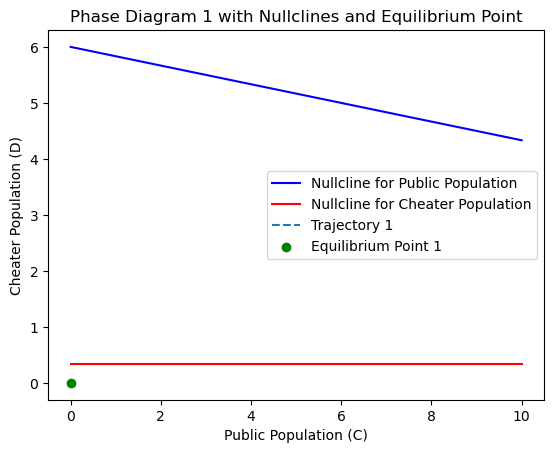

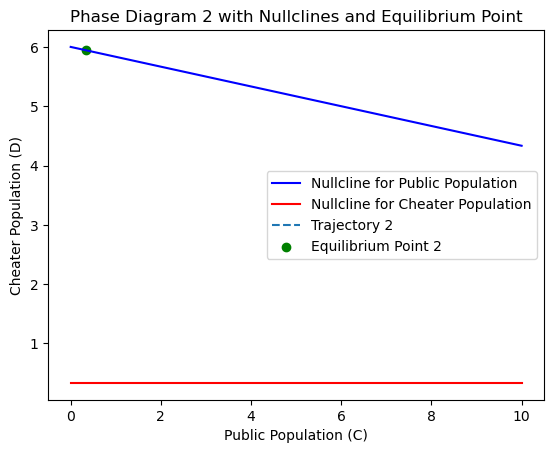

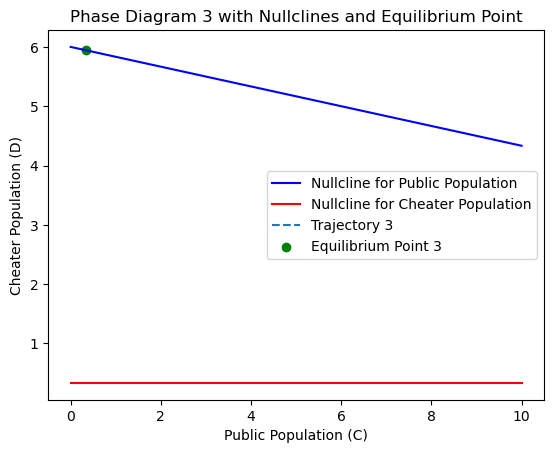

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve

# Define the Lotka-Volterra equations
def lv_equations(N, t, rc, alpha, nu, lambd):
    C, D = N
    dCdt = rc * C - alpha * C * D - lambd * C**2
    dDdt = alpha * C * D - nu * D
    return [dCdt, dDdt]

# Define the nullclines for the public and cheater populations
def nullcline_public(C, rc, alpha, lambd):
    return (rc - lambd * C) / alpha

def nullcline_cheater(C, alpha, nu):
    return np.full_like(C, nu / alpha)  # Ensure the same shape as C

# Parameters
rc = 1.8
alpha = 0.3
nu = 0.1
lambd = 0.05

# Time vector
t = np.linspace(0, 100, 1000)

# Find three equilibrium points
equilibrium_points = []
initial_guesses = [(1, 1), (5, 5), (10, 10)]

for initial_guess in initial_guesses:
    equilibrium = fsolve(lambda N: lv_equations(N, 0, rc, alpha, nu, lambd), initial_guess)
    equilibrium_points.append(equilibrium)

equilibrium_points = np.array(equilibrium_points)

# Nullcline values
C_values = np.linspace(0, 10, 100)
nullcline_public_values = nullcline_public(C_values, rc, alpha, lambd)
nullcline_cheater_values = nullcline_cheater(C_values, alpha, nu)

# Plot three phase diagrams
for i, equilibrium in enumerate(equilibrium_points):
    # Integrate the equations over the time grid, t.
    N = odeint(lv_equations, equilibrium, t, args=(rc, alpha, nu, lambd))
    
    # Plot the nullclines
    plt.plot(C_values, nullcline_public_values, label='Nullcline for Public Population', color='blue')
    plt.plot(C_values, nullcline_cheater_values, label='Nullcline for Cheater Population', color='red')
    
    # Plot the trajectory
    plt.plot(N[:, 0], N[:, 1], label=f'Trajectory {i+1}', linestyle='--')

    # Plot the equilibrium point
    plt.scatter(equilibrium[0], equilibrium[1], color='green', marker='o', label=f'Equilibrium Point {i+1}')

    # Label the axes
    plt.xlabel('Public Population (C)')
    plt.ylabel('Cheater Population (D)')

    # Add a legend
    plt.legend()

    # Add a title
    plt.title(f'Phase Diagram {i+1} with Nullclines and Equilibrium Point')

    # Show the plot
    plt.show()


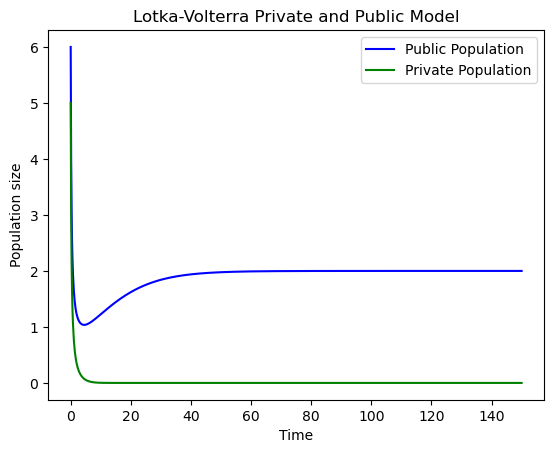

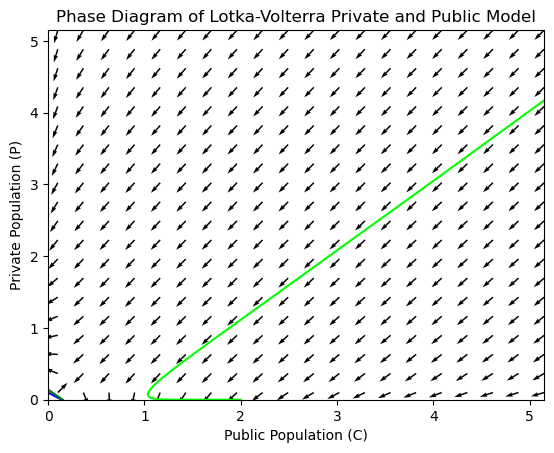

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function
def LVPrivatePublic(N, t, rc, beta, eta, gamma):
    """Lotka-Volterra Private and Public Model"""
    dCdt = rc * N[0] - beta * N[0] * N[1] - gamma * N[0]**2
    dPdt = eta * N[1] - beta * N[0] * N[1] - gamma * N[1]**2
    return np.array([dCdt, dPdt])

# Parameters values and initial conditions
rc = 0.1
beta = 0.66  # Change this parameter to obtain different scenarios
eta = 0.1
gamma = 0.05

NI = np.array([6, 5])  # Initial conditions (Initial population sizes)

# Time vector
t = np.linspace(0, 150, 1000)

# Solving the system of differential equations
sol = odeint(LVPrivatePublic, NI, t, args=(rc, beta, eta, gamma))

# Create the chart
plt.plot(t, sol[:, 0], color="blue", label="Public Population")
plt.plot(t, sol[:, 1], color="green", label="Private Population")
plt.legend(loc="upper right")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka-Volterra Private and Public Model")
plt.show()

# Phase Diagram
C = np.linspace(0, np.max([rc/beta, 0]) + 5, 100)
P = np.linspace(0, np.max([eta/beta, 0]) + 5, 100)

Null_C = (rc - beta * P - gamma * C) / beta
Null_P = eta - beta * C - gamma * P

C_max = np.max(C)
P_max = np.max(P)

x = np.linspace(0.1, C_max, 20)
y = np.linspace(0.1, P_max, 20)

xx, yy = np.meshgrid(x, y)

NNC, NNP = LVPrivatePublic((xx, yy), 0, rc, beta, eta, gamma)

norm = np.sqrt(NNC**2 + NNP**2)
NNC = NNC / norm
NNP = NNP / norm

plt.quiver(xx, yy, NNC, NNP, cmap=plt.cm.gray)
plt.plot(C, Null_P, color="blue")
plt.plot(Null_C, P, color="green")
plt.plot(sol[:, 0], sol[:, 1], color="lime")
plt.xlim(0, C_max)
plt.ylim(0, P_max)
plt.title("Phase Diagram of Lotka-Volterra Private and Public Model")
plt.xlabel("Public Population (C)")
plt.ylabel("Private Population (P)")
plt.show()


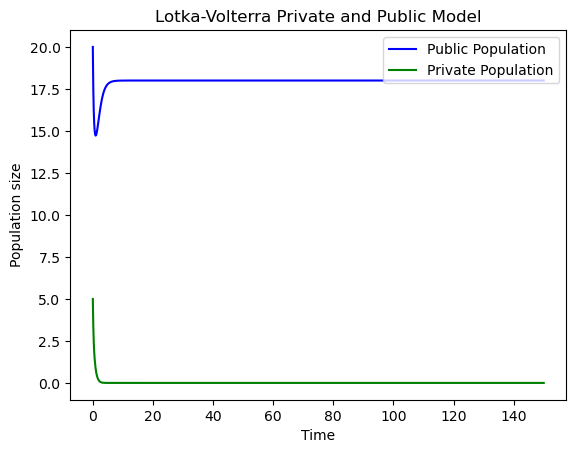

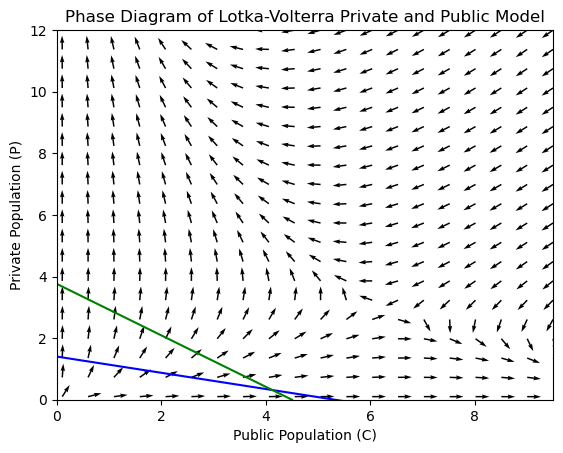

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the ODE function
def LVPrivatePublic(N, t, rc, beta, rp, gamma):
    """Lotka-Volterra Private and Public Model"""
    dCdt = rc * N[0] - beta * N[0] * N[1] - gamma * N[0]**2
    dPdt = rp * N[1] - beta * N[0] * N[1] - gamma * N[1]**2
    return np.array([dCdt, dPdt])

# Parameters values and initial conditions
rc = 0.9
beta = 0.2  # Change this parameter to obtain different scenarios
rp = 1.4
gamma = 0.05

NI = np.array([20, 5])  # Initial conditions (Initial population sizes)

# Time vector
t = np.linspace(0, 150, 1000)

# Solving the system of differential equations
sol = odeint(LVPrivatePublic, NI, t, args=(rc, beta, rp, gamma))

# Create the chart
plt.plot(t, sol[:, 0], color="blue", label="Public Population")
plt.plot(t, sol[:, 1], color="green", label="Private Population")
plt.legend(loc="upper right")
plt.xlabel("Time")
plt.ylabel("Population size")
plt.title("Lotka-Volterra Private and Public Model")
plt.show()

# Phase Diagram
C = np.linspace(0, np.max([rc/beta, 0]) + 5, 100)
P = np.linspace(0, np.max([rp/beta, 0]) + 5, 100)

Null_C = (rc - beta * P - gamma * C) / beta
Null_P = rp - beta * C - gamma * P

C_max = np.max(C)
P_max = np.max(P)

x = np.linspace(0.1, C_max, 20)
y = np.linspace(0.1, P_max, 20)

xx, yy = np.meshgrid(x, y)

NNC, NNP = LVPrivatePublic((xx, yy), 0, rc, beta, rp, gamma)

norm = np.sqrt(NNC**2 + NNP**2)
NNC = NNC / norm
NNP = NNP / norm

plt.quiver(xx, yy, NNC, NNP, cmap=plt.cm.gray)
plt.plot(C, Null_P, color="blue")
plt.plot(Null_C, P, color="green")
plt.plot(sol[:, 0], sol[:, 1], color="lime")
plt.xlim(0, C_max)
plt.ylim(0, P_max)
plt.title("Phase Diagram of Lotka-Volterra Private and Public Model")
plt.xlabel("Public Population (C)")
plt.ylabel("Private Population (P)")
plt.show()


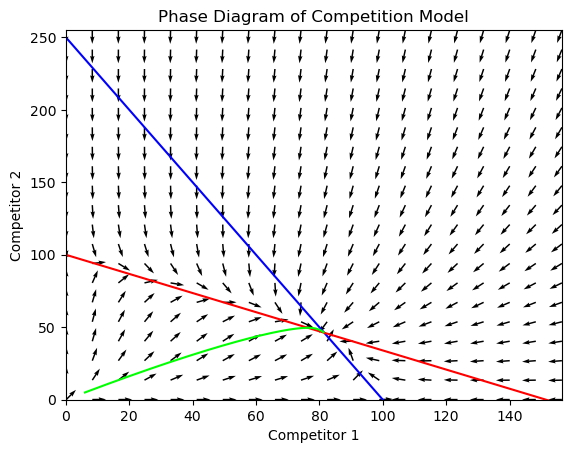

In [2]:
# 1. Import libraries
import numpy as np                   
import matplotlib.pyplot as plt      
import scipy as sci                  
from scipy import integrate


#2. Define the ODE function 
def LVC(N, t, r1, r2, alpha, beta, K1, K2):
    """Lotka-Volterra Competition Model"""
    dN_1 = r1*N[0] * (1 - (N[0] + alpha * N[1])/ K1)
    dN_2 = r2*N[1] * (1 - (N[1] + beta * N[0])/ K2)
    return(np.array([dN_1, dN_2]))

#3. Parameters values and initial conditions
r1 = 0.1
r2 = 0.1
alpha = 0.4 # Change this parameter to obtain different scenarios of LV model
beta = 0.66 # Change this parameter to obtain different scenarios of LV model
K1 = 100
K2 = 100

NI = np.array([6, 5]) # Initial conditions (Initial population sizes)

#4. Time vector
t = np.linspace(0, 150, 1000)

#5. Solving the system of differential equations
sol = sci.integrate.odeint(LVC, NI, t, args=(r1, r2, alpha, beta, K1, K2))

#6 Create the chart
#plt.plot(t, sol[:, 0], color = "blue", label = "Competitor 1")
#plt.plot(t, sol[:, 1], color = "red", label = "Competitor 2")
#plt.legend(loc = "upper right")
#plt.xlabel("Time")
#plt.ylabel("Population size")
#plt.show()




# Phase Diagram. Multiples scenarios
N_1 = np.linspace(0, np.max([K1, K2/beta])+5, 100)
N_2 = np.linspace(0, np.max([K2, K1/alpha])+5, 100)
Null_N1 = (K1 - N_1)/alpha
Null_N2 = K2 - beta * N_1

N1_max = np.max(N_1) # Max value of competitor 1
N2_max = np.max(N_2) # Max value of competitor 2
x = np.linspace(0.1, N1_max, 20) # Obtaining a vector with "X (here 20, see third argument)" values from 0 to N1_max"
y = np.linspace(0.1, N2_max, 20) # Obtaining a vector with "X (here 20, see third argument)" values from 0 to N2_max"
xx, yy = np.meshgrid(x, y) # Creating a meshgrid with points where the vector will be drawn.
NN1, NN2 = LVC((xx, yy), 0, r1, r2, alpha, beta, K1, K2) # Derivate each point of the Phase Diagram (it will create the vector field)
norm = np.sqrt(NN1**2 + NN2**2)
NN1 = NN1 / norm
NN2 = NN2 / norm
plt.quiver(xx, yy, NN1, NN2, cmap=plt.cm.gray) #
plt.plot(N_1, Null_N1, color = "blue")
plt.plot(N_1, Null_N2, color = "red")
plt.plot(sol[:, 0], sol[:, 1], color = "lime")
plt.xlim(0, N1_max)
plt.ylim(0, N2_max)
plt.title("Phase Diagram of Competition Model")
plt.xlabel("Competitor 1")
plt.ylabel("Competitor 2")
plt.show() 

In [2]:
from sympy import symbols, Eq, solve

# Define symbols
C, D, P = symbols('C D P')
rc, rp, alpha, beta, nu, eta, lambda_, gamma = symbols('rc rp alpha beta nu eta lambda gamma')

# Define equations
eq1 = Eq(rc*C - alpha*C*D - beta*C*P - lambda_*C**2, 0)
eq2 = Eq(alpha*C*D - nu*D, 0)
eq3 = Eq(rp*P - eta*P*C - gamma*P**2, 0)

# Solve the system of equations
equilibrium_points = solve((eq1, eq2, eq3), (C, D, P))

equilibrium_points


[(0, 0, 0),
 (0, 0, rp/gamma),
 (nu/alpha, (alpha*rc - lambda*nu)/alpha**2, 0),
 (nu/alpha,
  -(alpha*beta*rp - alpha*gamma*rc - beta*eta*nu + gamma*lambda*nu)/(alpha**2*gamma),
  (alpha*rp - eta*nu)/(alpha*gamma)),
 (rc/lambda, 0, 0),
 ((beta*rp - gamma*rc)/(beta*eta - gamma*lambda),
  0,
  (eta*rc - lambda*rp)/(beta*eta - gamma*lambda))]

#  public , Private and cheater(3 members stability analysis)




### Equilibrium Point 4: 

$\left(\frac{\beta r_p - \gamma r_c}{\beta \eta - \gamma \lambda}, 0, \frac{\eta r_c - \lambda r_p}{\beta \eta - \gamma \lambda}\right)$

For this equilibrium point, the Jacobian matrix \(J\) is given by:


$$J_4 = \begin{bmatrix} 
r_c - 2 \lambda \cdot \frac{\beta r_p - \gamma r_c}{\beta \eta - \gamma \lambda} & -\alpha \cdot \frac{\beta r_p - \gamma r_c}{\beta \eta - \gamma \lambda} & -\beta \cdot \frac{\eta r_c - \lambda r_p}{\beta \eta - \gamma \lambda} \\ 
\alpha \cdot \frac{\beta r_p - \gamma r_c}{\beta \eta - \gamma \lambda} & -2 \nu \cdot 0 & 0 \\ 
-\eta \cdot \frac{\beta r_p - \gamma r_c}{\beta \eta - \gamma \lambda} & 0 & r_p - 2 \gamma \cdot \frac{\eta r_c - \lambda r_p}{\beta \eta - \gamma \lambda} 
\end{bmatrix}
$$

Simplifying, we get:

$$
J_4 = \begin{bmatrix} 
\frac{r_c(\beta\eta - \gamma\lambda) - 2\lambda(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda} & -\frac{\alpha(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda} & -\frac{\beta(\eta r_c - \lambda r_p)}{\beta \eta - \gamma \lambda} \\ 
\frac{\alpha(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda} & 0 & 0 \\ 
-\frac{\eta(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda} & 0 & \frac{r_p(\beta\eta - \gamma\lambda) - 2\gamma(\eta r_c - \lambda r_p)}{\beta \eta - \gamma \lambda} 
\end{bmatrix}
$$

Now, let's find the eigenvalues of $J_4 $.

To find the eigenvalues of $J_4 $, we need to solve the characteristic equation:

$$
\text{det}(J_4 - \lambda I) = 0
$$

where $I $ is the identity matrix.

Let's denote the elements of $J_4$ as follows:

$$
a = \frac{r_c(\beta\eta - \gamma\lambda) - 2\lambda(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda}
$$
$$
b = -\frac{\alpha(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda}
$$
$$
c = -\frac{\beta(\eta r_c - \lambda r_p)}{\beta \eta - \gamma \lambda}
$$
$$
d = -\frac{\eta(\beta r_p - \gamma r_c)}{\beta \eta - \gamma \lambda}
$$
$$
e = \frac{r_p(\beta\eta - \gamma\lambda) - 2\gamma(\eta r_c - \lambda r_p)}{\beta \eta - \gamma \lambda}
$$

Then, the characteristic equation becomes:

$$
\text{det}\left(\begin{bmatrix} a-\lambda & b & c \\ \alpha & -\lambda & 0 \\ d & 0 & e-\lambda \end{bmatrix}\right) = 0
$$

Expanding the determinant, we get a polynomial equation in $\lambda $. Solving this polynomial equation will give us the eigenvalues.



Expanding the determinant, we get:

$$
(a - \lambda) \cdot [(-\lambda) \cdot (e - \lambda) - 0 \cdot 0] - b \cdot [\alpha \cdot (e - \lambda) - 0 \cdot d] + c \cdot [\alpha \cdot 0 - (-\lambda) \cdot d] = 0
$$

$$
(a - \lambda)((-\lambda)(e - \lambda)) - b(\alpha(e - \lambda)) + c(-\lambda d) = 0
$$

Solving this polynomial equation will give us the eigenvalues of $J_4 $.


Certainly! Let's solve the equation step by step.

Given polynomial equation:
$$
(a - \lambda)((-\lambda)(e - \lambda)) - b(\alpha(e - \lambda)) + c(-\lambda d) = 0
$$

Expanding the terms, we have:
$$
(-\lambda^2 + (a + \alpha b)\lambda - ae)(-\lambda + e) - cd\lambda = 0
$$

Expanding further:
$$
-\lambda^3 + (a + \alpha b + e)\lambda^2 - (ae + \alpha be + cd)\lambda + cde = 0
$$

Now, we have a cubic equation in the form $(ax^3 + bx^2 + cx + d = 0)$, where:
$$
\begin{align*}
a &= -1 \\
b &= (a + \alpha b + e) \\
c &= -(ae + \alpha be + cd) \\
d &= cde
\end{align*}
$$








# Equilibium point 5


 

Given the Jacobian matrix $J_5 $ at equilibrium point 5:

$$
J_5 = \begin{bmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & 0 
\end{bmatrix}
$$

where $$a = \frac{\nu r_c}{\alpha^2 + \lambda \nu}$$, $$b = \frac{\alpha r_c}{\alpha^2 + \lambda \nu} $$, and $$ c = 0 $$.

The characteristic equation is:

$$
\text{det}(J_5 - \lambda I) = \begin{vmatrix} 
a - \lambda & b & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & -\lambda 
\end{vmatrix} = 0
$$

Expanding the determinant, we get:

$$
(a - \lambda)((-\lambda)(-\lambda)) - b(\alpha(-\lambda)) = 0
$$

Solving this equation will give us the eigenvalues $\lambda $ of $J_5 $ .

To solve for the eigenvalues of \(J_5\), let's write down the characteristic equation and solve it.

Given the Jacobian matrix \(J_5\) at equilibrium point 5:

$$
J_5 = \begin{bmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & 0 
\end{bmatrix}
$$

The characteristic equation is:

\[
\text{det}(J_5 - \lambda I) = \begin{vmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda - \lambda & 0 \\ 
0 & 0 & -\lambda 
\end{vmatrix} = 0
\]

Expanding the determinant, we get:

\[
\left(\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda\right) \cdot (-\lambda) \cdot (-\lambda) - \frac{\alpha r_c}{\alpha^2 + \lambda \nu} \cdot \alpha \cdot (-\lambda) = 0
\]

Solving this equation will give us the eigenvalues \(\lambda\) of \(J_5\). Let's proceed with this calculation.

To solve for the eigenvalues of \(J_5\), let's write down the characteristic equation and solve it.

Given the Jacobian matrix \(J_5\) at equilibrium point 5:

\[
J_5 = \begin{bmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & 0 
\end{bmatrix}
\]

The characteristic equation is:

\[
\text{det}(J_5 - \lambda I) = \begin{vmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda - \lambda & 0 \\ 
0 & 0 & -\lambda 
\end{vmatrix} = 0
\]

Expanding the determinant, we get:

\[
\left(\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda\right) \cdot (-\lambda) \cdot (-\lambda) - \frac{\alpha r_c}{\alpha^2 + \lambda \nu} \cdot \alpha \cdot (-\lambda) = 0
\]

Solving this equation will give us the eigenvalues \(\lambda\) of \(J_5\). Let's proceed with this calculation.

To solve for the eigenvalues of \(J_5\), we need to write down the characteristic equation and solve it.

Given the Jacobian matrix \(J_5\) at equilibrium point 5:

\[
J_5 = \begin{bmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & 0 
\end{bmatrix}
\]

The characteristic equation is:

\[
\text{det}(J_5 - \lambda I) = \begin{vmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & -\lambda 
\end{vmatrix} = 0
\]

Expanding the determinant, we get:

\[
\left(\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda\right) \cdot (-\lambda) \cdot (-\lambda) - \frac{\alpha r_c}{\alpha^2 + \lambda \nu} \cdot \alpha \cdot (-\lambda) = 0
\]

Solving this equation will give us the eigenvalues \(\lambda\) of \(J_5\). Let's proceed with this calculation.

The characteristic equation for \(J_5\) is obtained by taking the determinant of \(J_5 - \lambda I\), where \(I\) is the identity matrix. The resulting polynomial equation is then solved to find the eigenvalues \(\lambda\).

Given the Jacobian matrix \(J_5\) at equilibrium point 5:

\[
J_5 = \begin{bmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & 0 
\end{bmatrix}
\]

The characteristic equation is:

\[
\text{det}(J_5 - \lambda I) = \begin{vmatrix} 
\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda & \frac{\alpha r_c}{\alpha^2 + \lambda \nu} & 0 \\ 
\alpha & -\lambda & 0 \\ 
0 & 0 & -\lambda 
\end{vmatrix} = 0
\]

Expanding the determinant, we get:

\[
\left(\frac{\nu r_c}{\alpha^2 + \lambda \nu} - \lambda\right) \cdot (-\lambda) \cdot (-\lambda) - \frac{\alpha r_c}{\alpha^2 + \lambda \nu} \cdot \alpha \cdot (-\lambda) = 0
\

## Game theory


### 1. **Strategic Interactions and Payoff Matrix**

**Strategic Interactions**:

In any ecological system, individuals or species engage in various interactions that affect their survival and reproduction. These interactions can be cooperative, competitive, or exploitative. In the context of microbial communities:

- **Cooperators (C)** contribute to the community by producing a public good. For example, they might secrete enzymes that break down complex nutrients into simpler forms that all members of the community can use. The public good benefits everyone, but cooperators bear the cost of production.
- **Cheaters (D)** exploit the public good without contributing to its production. They save energy by not producing the good themselves, but they still gain the benefits. This creates a dilemma because if too many individuals choose to cheat, the public good may be underproduced or not produced at all, leading to the collapse of the cooperative system.
- **Private Benefit Species (P)** are organisms that focus on their own survival strategies independent of the public good. They compete for resources or niches that are not directly related to the cooperative effort but can still affect the overall community dynamics.

**Payoff Matrix**:

The payoff matrix is a tool used to quantify the benefits (or fitness) that individuals gain from their interactions. Each entry in the matrix represents the fitness payoff to an individual of a particular type (C, D, or P) when interacting with another individual of the same or different type.

The payoffs are influenced by several factors:
- **Intrinsic Growth Rate**: This is the natural rate at which a population grows in the absence of interactions with other types. For cooperators (\(r_c\)) and private benefit species (\(r_p\)), this rate is positive, reflecting their ability to grow independently.
- **Interaction Effects**: These include the negative impacts of one population on another, such as the exploitation by cheaters (\(\alpha \cdot C \cdot D\)) or competition for resources (\(\beta \cdot C \cdot P\)). These terms reduce the overall fitness of a population depending on the densities of other populations.
- **Density-Dependent Constraints**: As populations grow, they may encounter limitations due to resource depletion, overcrowding, or other factors. This is reflected in the quadratic terms (\(\lambda \cdot C^2\) and \(\gamma \cdot P^2\)), which impose a carrying capacity-like effect on the populations.

**Implications**:
- **Conflict Between Cooperators and Cheaters**: The interaction between cooperators and cheaters is central to the system's dynamics. Cooperators provide a benefit that cheaters exploit, but if cheaters become too numerous, they can undermine the system that supports them, leading to a collapse in both populations.
- **Role of Private Benefit Species**: These species can affect the balance between cooperators and cheaters by competing for shared resources. Their presence introduces additional complexity to the system, potentially destabilizing it or creating new stable states.

### 2. **Replicator Dynamics and Population Dynamics**

**Replicator Dynamics**:

Replicator dynamics describe how the proportion of each strategy (or population) changes over time based on the relative fitness of each strategy. In this framework, strategies that perform well (i.e., have higher payoffs) increase in frequency, while those that perform poorly decrease.

The basic equation for replicator dynamics is:
\[
\frac{dx_i}{dt} = x_i \left( \pi_i - \bar{\pi} \right)
\]
Where:
- \(x_i\) is the proportion of strategy \(i\) in the population.
- \(\pi_i\) is the payoff to strategy \(i\).
- \(\bar{\pi}\) is the average payoff of the population, which normalizes the growth rates.

**Population Dynamics**:

While replicator dynamics focus on relative frequencies, population dynamics consider the absolute sizes of the populations. The quadratic Lotka-Volterra equations describe how the actual numbers of cooperators (C), cheaters (D), and private benefit species (P) change over time.

These equations incorporate:
- **Intrinsic Growth Rates**: The natural tendencies of the populations to grow based on their respective fitness.
- **Interaction Terms**: These capture the effects of one population on another. For example, cooperators might suffer if cheaters become too numerous, reducing the public good's availability.
- **Density-Dependent Effects**: As populations grow, they may face resource limitations or other constraints that slow their growth.

The equations take the form:
\[
\frac{dC}{dt} = C \cdot \left( r_c - \alpha \cdot D - \beta \cdot P - \lambda \cdot C \right)
\]
\[
\frac{dD}{dt} = D \cdot \left( \alpha \cdot C - \nu \right)
\]
\[
\frac{dP}{dt} = P \cdot \left( r_p - \eta \cdot C - \gamma \cdot P \right)
\]
Here, each term represents a different force acting on the population: growth, competition, exploitation, and self-limitation.

**Implications**:
- **Coupled Dynamics**: The fate of each population is intertwined with the others. For example, an increase in cheaters might lead to a decrease in cooperators, which could in turn affect private benefit species if they rely indirectly on the cooperators.
- **Nonlinear Effects**: The quadratic terms introduce nonlinearity into the dynamics, meaning small changes in population sizes can lead to disproportionately large effects, including potential population crashes or booms.

### 3. **Stability Analysis and Evolutionarily Stable Strategies (ESS)**

**Stability Analysis**:

Stability analysis involves finding the equilibrium points of the system—situations where the populations remain constant over time—and determining whether these points are stable or unstable. This is done by solving the system of differential equations for points where:
\[
\frac{dC}{dt} = \frac{dD}{dt} = \frac{dP}{dt} = 0
\]
Once these points are found, the stability is determined by analyzing the Jacobian matrix at these points. The Jacobian matrix represents how small perturbations in population sizes affect the growth rates of the populations.

The stability of an equilibrium is determined by the eigenvalues of the Jacobian:
- **Negative Eigenvalues**: The equilibrium is stable, meaning small deviations from this point will decay over time, and the system will return to equilibrium.
- **Positive Eigenvalues**: The equilibrium is unstable, meaning small deviations will grow over time, leading the system away from this point.

**Evolutionarily Stable Strategies (ESS)**:

An ESS is a strategy (or set of strategies) that, if adopted by a population, cannot be invaded by a mutant strategy because it provides a higher fitness. In the context of our system:
- **Cooperators** might represent an ESS if they can maintain a population despite the presence of cheaters. This could occur if the benefit of cooperation is high enough or if cheaters are sufficiently penalized (e.g., by \(\nu\)).
- **Cheaters** could be an ESS if they can successfully exploit cooperators without driving them to extinction, ensuring a continued source of the public good.
- **Private Benefit Species** might form an ESS if they can carve out a niche where they are not directly competing with cooperators or cheaters for the same resources.

**Implications**:
- **Resilience and Persistence**: An ESS represents a resilient state of the system where the population can persist over time, resisting invasion by alternative strategies.
- **Multiple Equilibria**: Depending on the initial conditions and parameter values, the system might have multiple stable points (bistability), meaning that the outcome could depend heavily on the starting populations.
- **Dynamic Stability**: Even if a population is at an ESS, the system might still exhibit complex dynamics, such as oscillations or cycles, where populations fluctuate but remain within a certain range.

### **Conclusion**

In summary, the combination of strategic interactions, replicator dynamics, and stability analysis provides a comprehensive framework for understanding the behavior of complex ecological systems. By modeling how different populations interact, grow, and stabilize (or destabilize), we can gain insights into the conditions that promote cooperation, the persistence of cheating, and the survival of diverse strategies within a community.

These concepts are not only relevant for microbial communities but can also be applied to a wide range of biological and ecological systems, from animal behavior to human social dynamics, where similar principles of cooperation, competition, and strategy play a crucial role in shaping evolutionary outcomes.

## Payoff

 Payoff matrix based on the interactions described in the context of the Quadratic Lotka-Volterra model for microbial communities, focusing on Cooperators (C), Cheaters (D), and Private Benefit Species (P).

### Payoff Matrix Structure

The payoff matrix will have rows and columns representing the three types of strategies (C, D, P). Each cell in the matrix represents the fitness (or payoff) of a row strategy when it interacts with a column strategy. 

In this context:
- **Fitness** is determined by the growth rates and the interactions between populations.
- **C (Cooperator)**: Gains a payoff that is reduced by interactions with Cheaters (D) and Private Benefit Species (P).
- **D (Cheater)**: Gains a payoff by exploiting Cooperators without contributing to the public good.
- **P (Private Benefit Species)**: Gains a payoff based on its own growth strategy, largely independent of the public good but still affected by the presence of C and D.

### Payoff Matrix Explanation

Let's define the payoff matrix $ M $ as follows:

$$
M = \begin{pmatrix}
\pi_{C,C} & \pi_{C,D} & \pi_{C,P} \\
\pi_{D,C} & \pi_{D,D} & \pi_{D,P} \\
\pi_{P,C} & \pi_{P,D} & \pi_{P,P} 
\end{pmatrix}
$$

Where:
- $ \pi_{X,Y} $  is the payoff to strategy $ X $ when interacting with strategy $ Y $.

### Payoff Matrix Values

Given the interactions in the model:

1. **\( \pi_{C,C} \) (Cooperator interacting with Cooperator)**:
   - Cooperators benefit from each other through the production of the public good. However, they also face a density-dependent limitation.
   - \( \pi_{C,C} = r_c - \lambda C \)

2. **\( \pi_{C,D} \) (Cooperator interacting with Cheater)**:
   - Cooperators lose some fitness due to the exploitation by cheaters.
   - \( \pi_{C,D} = r_c - \alpha D - \lambda C \)

3. **\( \pi_{C,P} \) (Cooperator interacting with Private Benefit Species)**:
   - Cooperators are affected by competition with private benefit species.
   - \( \pi_{C,P} = r_c - \beta P - \lambda C \)

4. **\( \pi_{D,C} \) (Cheater interacting with Cooperator)**:
   - Cheaters gain by exploiting cooperators without incurring the cost of producing the public good.
   - \( \pi_{D,C} = \alpha C - \nu \)

5. **\( \pi_{D,D} \) (Cheater interacting with Cheater)**:
   - Cheaters neither contribute nor benefit directly from each other. They may experience a reduction in fitness due to lack of available resources as the public good diminishes.
   - \( \pi_{D,D} = -\nu \)

6. **\( \pi_{D,P} \) (Cheater interacting with Private Benefit Species)**:
   - Cheaters do not directly interact with private benefit species in a way that affects their payoff, so the payoff is primarily the negative growth due to the absence of cooperators.
   - \( \pi_{D,P} = -\nu \)

7. **\( \pi_{P,C} \) (Private Benefit Species interacting with Cooperator)**:
   - Private benefit species may compete with cooperators for resources, which affects their fitness.
   - \( \pi_{P,C} = r_p - \eta C - \gamma P \)

8. **\( \pi_{P,D} \) (Private Benefit Species interacting with Cheater)**:
   - The private benefit species’ fitness is primarily independent of cheaters but may still be reduced slightly due to indirect competition.
   - \( \pi_{P,D} = r_p - \gamma P \)

9. **\( \pi_{P,P} \) (Private Benefit Species interacting with Private Benefit Species)**:
   - They primarily compete among themselves, which reduces their growth as their population increases.
   - \( \pi_{P,P} = r_p - \gamma P \)

### **Complete Payoff Matrix**

Now, let's place these values into the matrix:

\[
M = \begin{pmatrix}
r_c - \lambda C & r_c - \alpha D - \lambda C & r_c - \beta P - \lambda C \\
\alpha C - \nu & -\nu & -\nu \\
r_p - \eta C - \gamma P & r_p - \gamma P & r_p - \gamma P 
\end{pmatrix}
\]

### **Interpreting the Matrix**

- **Diagonal Elements**: These represent the fitness of each type when interacting with itself. The diagonal shows the impact of internal competition and density-dependent factors (such as carrying capacity effects).
- **Off-Diagonal Elements**: These capture the interactions between different strategies. For instance, \( \pi_{C,D} \) shows how cooperators lose fitness due to cheaters, while \( \pi_{D,C} \) shows how cheaters benefit from cooperators.

### **Implications of the Payoff Matrix**

- The matrix highlights the conflict between cooperators and cheaters, where cooperators incur a cost to produce a public good that cheaters exploit. 
- The presence of private benefit species adds another layer of competition that can influence the balance between cooperators and cheaters. 
- The stability and dynamics of the population will depend on these payoffs, influencing which strategies are favored over time.

This payoff matrix serves as a foundational tool for analyzing the strategic dynamics in this ecological system, leading to further insights through replicator dynamics and stability analysis.

the payoff matrices for both the Lotka-Volterra model and the Lotka-Volterra model with logistic growth, focusing on the microbial community with three strains: public metabolizer, private metabolizer, and cheater.

## Lotka-Volterra Model

The basic Lotka-Volterra model for the three-strain microbial community is described by the following equations:

$$
\begin{aligned}
\frac{dC}{dt} &= r_c \cdot C - \alpha \cdot C \cdot D - \beta \cdot C \cdot P \\
\frac{dD}{dt} &= \alpha C \cdot D - \nu \cdot D \\
\frac{dP}{dt} &= r_p \cdot P - \eta P \cdot C
\end{aligned}
$$

Where C, D, and P represent the populations of public metabolizer, cheater, and private metabolizer respectively[1].

### Payoff Matrix for Lotka-Volterra Model

The payoff matrix for this model can be interpreted as follows:

| Strategy | Public (C) | Cheater (D) | Private (P) |
|----------|------------|-------------|-------------|
| Public (C) | $r_c$ | $-\alpha$ | $-\beta$ |
| Cheater (D) | $\alpha$ | $-\nu$ | 0 |
| Private (P) | $-\eta$ | 0 | $r_p$ |

Interpretation:
- Public metabolizers (C) have a natural growth rate $r_c$ but suffer negative effects from interactions with cheaters ($-\alpha$) and private metabolizers ($-\beta$).
- Cheaters (D) benefit from public metabolizers ($\alpha$) but have a natural mortality rate ($-\nu$).
- Private metabolizers (P) have a natural growth rate $r_p$ but are negatively affected by public metabolizers ($-\eta$).

## Lotka-Volterra Model with Logistic Growth

The Lotka-Volterra model with logistic growth introduces carrying capacity terms for the public and private metabolizers:

$$
\begin{aligned}
\frac{dC}{dt} &= r_c \cdot C - \alpha \cdot C \cdot D - \beta \cdot C \cdot P - \lambda \cdot C^2 \\
\frac{dD}{dt} &= \alpha C \cdot D - \nu \cdot D \\
\frac{dP}{dt} &= r_P \cdot P - \eta P \cdot C - \gamma \cdot P^2
\end{aligned}
$$

Where $\lambda$ and $\gamma$ are related to the carrying capacities of public and private metabolizers respectively[1].

### Payoff Matrix for Lotka-Volterra Model with Logistic Growth

The payoff matrix for this model can be interpreted as:

| Strategy | Public (C) | Cheater (D) | Private (P) |
|----------|------------|-------------|-------------|
| Public (C) | $r_c - \lambda C$ | $-\alpha$ | $-\beta$ |
| Cheater (D) | $\alpha$ | $-\nu$ | 0 |
| Private (P) | $-\eta$ | 0 | $r_p - \gamma P$ |

Interpretation:
- Public metabolizers (C) now have a growth rate that depends on their own population size ($r_c - \lambda C$), reflecting the logistic growth.
- Cheaters (D) remain unchanged from the basic model.
- Private metabolizers (P) also have a logistic growth term ($r_p - \gamma P$).

## Key Differences and Implications

1. **Density dependence**: The logistic growth model introduces self-limiting factors for public and private metabolizers, which is more realistic in many biological scenarios[1].

2. **Carrying capacity**: The terms $\lambda C^2$ and $\gamma P^2$ represent the effects of resource limitations on the respective populations.

3. **Stability**: The logistic growth model may lead to more stable equilibria compared to the basic Lotka-Volterra model, as it prevents unlimited growth of any population[1].

4. **Coexistence**: The logistic growth model may allow for more scenarios of coexistence between the three strains, as it prevents any single strain from dominating indefinitely.

5. **Strategic implications**: In the logistic model, the optimal strategies for public and private metabolizers may change as their populations approach carrying capacity, potentially leading to more complex dynamics and evolutionary outcomes.

By analyzing these payoff matrices, researchers can gain insights into the potential outcomes of interactions between the three strains and predict which strategies might be favored under different conditions. This approach combines elements of game theory with population dynamics, providing a powerful tool for understanding microbial community interactions.


##fitness funtion


The **replicator dynamics equation** describes how the proportion of individuals using each strategy changes over time in response to the relative fitness of those strategies. For each model, the basic form of the replicator dynamics equation remains the same, but the way we calculate the fitness depends on the specific payoffs.

### General Form of Replicator Dynamics:

The general equation for replicator dynamics is:

\[
\frac{dx_i}{dt} = x_i \left( f_i - \bar{f} \right)
\]

Where:
- \( x_i \) is the proportion of the population using strategy \( i \).
- \( f_i \) is the fitness (payoff) of strategy \( i \).
- \( \bar{f} \) is the average fitness of the population.
- \( \frac{dx_i}{dt} \) represents the rate of change of the proportion of players using strategy \( i \) over time.

The term \( f_i - \bar{f} \) represents the difference between the fitness of strategy \( i \) and the average fitness of the population. If \( f_i > \bar{f} \), strategy \( i \) increases in proportion, and if \( f_i < \bar{f} \), it decreases.

Now, let’s break down the fitness calculations for the two payoff matrices.

---

### 1. **Replicator Dynamics for the First Payoff Matrix (Without Competition Effects)**

In the **first model**, the fitness of each strategy is determined solely by the payoff matrix. Let the strategies be **Public (C)**, **Cheater (D)**, and **Private (P)**. The fitness of each strategy \( f_C \), \( f_D \), and \( f_P \) depends on how frequently each strategy is used in the population and the payoffs from interactions.

Let:
- \( x_C \) be the proportion of the population playing **Public (C)**.
- \( x_D \) be the proportion of the population playing **Cheater (D)**.
- \( x_P \) be the proportion of the population playing **Private (P)**.

The fitness of each strategy can be calculated as the weighted average of the payoffs from interacting with all other strategies in the population:

\[
f_C = r_c x_C + (r_c - \alpha) x_D + (r_c - \beta) x_P
\]
\[
f_D = \alpha x_C - \nu x_D
\]
\[
f_P = (r_p - \eta) x_C + r_p x_P
\]

Here, the fitness of Public, Cheater, and Private depends on the payoff for interactions with others. For example, \( f_C \) for Public players is higher when more players choose Public (because they earn \( r_c \)) but decreases when more players are Cheaters or Privates.

The **average fitness** of the population \( \bar{f} \) is:

\[
\bar{f} = x_C f_C + x_D f_D + x_P f_P
\]

Using these fitness functions, we can apply the replicator dynamics equation:

\[
\frac{dx_C}{dt} = x_C (f_C - \bar{f})
\]
\[
\frac{dx_D}{dt} = x_D (f_D - \bar{f})
\]
\[
\frac{dx_P}{dt} = x_P (f_P - \bar{f})
\]

These equations describe how the proportions of Public, Cheater, and Private players change over time, depending on their fitness relative to the population's average fitness.

---

### 2. **Replicator Dynamics for the Second Payoff Matrix (With Competition Effects)**

In the **second model**, competition effects are added, meaning that the fitness of Public and Private strategies decreases as more players adopt them. The equations for fitness are modified to include these effects.

Again, let \( x_C \), \( x_D \), and \( x_P \) be the proportions of Public, Cheater, and Private strategies in the population.

The fitness functions for each strategy are now:

\[
f_C = r_c - \lambda x_C + (r_c - \alpha) x_D + (r_c - \beta) x_P
\]
\[
f_D = \alpha x_C - \nu x_D
\]
\[
f_P = (r_p - \eta) x_C + r_p - \gamma x_P
\]

- \( r_c - \lambda x_C \): The fitness of Public players is reduced as more players adopt the Public strategy, due to the competition effect \( \lambda x_C \).
- \( r_p - \gamma x_P \): The fitness of Private players is similarly reduced as more players adopt the Private strategy, due to the competition effect \( \gamma x_P \).

The **average fitness** of the population \( \bar{f} \) is:

\[
\bar{f} = x_C f_C + x_D f_D + x_P f_P
\]

The replicator dynamics equations for this model are:

\[
\frac{dx_C}{dt} = x_C (f_C - \bar{f})
\]
\[
\frac{dx_D}{dt} = x_D (f_D - \bar{f})
\]
\[
\frac{dx_P}{dt} = x_P (f_P - \bar{f})
\]

In this model, the competition effects \( \lambda x_C \) and \( \gamma x_P \) reduce the fitness of Public and Private strategies as their frequencies increase. This leads to more complex dynamics where the system is less likely to settle into pure equilibria and more likely to evolve toward mixed equilibria, where multiple strategies coexist.

---

### Summary of Differences:
- **First Model**: Fitness is determined by payoffs from interactions between strategies. The system tends to move toward pure equilibria, where one strategy dominates based on the highest payoff.
- **Second Model**: Fitness is influenced by both payoffs and competition effects. As more players adopt Public or Private strategies, their fitness decreases, promoting the likelihood of mixed equilibria, where multiple strategies coexist. 

In both models, the replicator dynamics equations describe how the proportions of strategies change over time, but the second model introduces more complexity through competition effects.